In [2]:
import pandas as pd

# Example: Income Statement Data
data = {
    "Item": [
        "Revenue", "Cost of Sales", "Gross Profit", "Other Operating Income",
        "Selling Expenses", "R&D Expenses", "G&A Expenses", "Goodwill Impairment",
        "Other Operating Expenses", "Operating Profit", "Share of Profit of Associates",
        "Other Investment Income", "Profit Before Financing & Taxes",
        "Interest Expense Borrowings", "Interest Expense Pensions",
        "Profit Before Tax", "Income Tax Expense", "Profit from Continuing Ops",
        "Loss from Discontinued Ops", "Profit for the Year"
    ],
    "20X4": [
        80000, -32000, 48000, 3500, -10000, -4000, -15000, -1000, -3000, 18500,
        2000, 1500, 22000, -5000, -1500, 15500, -3000, 12500, -1200, 11300
    ],
    "20X3": [
        75000, -30000, 45000, 3000, -9000, -3500, -14000, -500, -2500, 18500,
        1800, 1200, 21500, -4800, -1200, 15500, -2800, 12700, -1000, 11700
    ]
}

df = pd.DataFrame(data)
print(df)


                               Item   20X4   20X3
0                           Revenue  80000  75000
1                     Cost of Sales -32000 -30000
2                      Gross Profit  48000  45000
3            Other Operating Income   3500   3000
4                  Selling Expenses -10000  -9000
5                      R&D Expenses  -4000  -3500
6                      G&A Expenses -15000 -14000
7               Goodwill Impairment  -1000   -500
8          Other Operating Expenses  -3000  -2500
9                  Operating Profit  18500  18500
10    Share of Profit of Associates   2000   1800
11          Other Investment Income   1500   1200
12  Profit Before Financing & Taxes  22000  21500
13      Interest Expense Borrowings  -5000  -4800
14        Interest Expense Pensions  -1500  -1200
15                Profit Before Tax  15500  15500
16               Income Tax Expense  -3000  -2800
17       Profit from Continuing Ops  12500  12700
18       Loss from Discontinued Ops  -1200  -1000


In [6]:
display(df)

,Item,20X4,20X3
0,Revenue,80000,75000
1,Cost of Sales,-32000,-30000
2,Gross Profit,48000,45000
3,Other Operating Income,3500,3000
4,Selling Expenses,-10000,-9000
5,R&D Expenses,-4000,-3500
6,G&A Expenses,-15000,-14000
7,Goodwill Impairment,-1000,-500
8,Other Operating Expenses,-3000,-2500
9,Operating Profit,18500,18500


In [3]:
balance_sheet = {
    "Item": ["Current Assets", "Inventory", "Cash", "Current Liabilities"],
    "20X4": [25000, 6000, 10000, 15000],
    "20X3": [22900, 5500, 9000, 13800]
}

bs = pd.DataFrame(balance_sheet)
print(bs)


                  Item   20X4   20X3
0       Current Assets  25000  22900
1            Inventory   6000   5500
2                 Cash  10000   9000
3  Current Liabilities  15000  13800


In [7]:
display(bs)

,Item,20X4,20X3
0,Current Assets,25000,22900
1,Inventory,6000,5500
2,Cash,10000,9000
3,Current Liabilities,15000,13800


In [4]:
# Liquidity Ratios
def liquidity_ratios(bs, year):
    current_assets = bs.loc[bs["Item"]=="Current Assets", year].values[0]
    inventory = bs.loc[bs["Item"]=="Inventory", year].values[0]
    cash = bs.loc[bs["Item"]=="Cash", year].values[0]
    current_liabilities = bs.loc[bs["Item"]=="Current Liabilities", year].values[0]

    current_ratio = current_assets / current_liabilities
    quick_ratio = (current_assets - inventory) / current_liabilities
    cash_ratio = cash / current_liabilities
    working_capital = current_assets - current_liabilities

    return {
        "Current Ratio": round(current_ratio, 2),
        "Quick Ratio": round(quick_ratio, 2),
        "Cash Ratio": round(cash_ratio, 2),
        "Working Capital": working_capital
    }

ratios_20X4 = liquidity_ratios(bs, "20X4")
ratios_20X3 = liquidity_ratios(bs, "20X3")

print("Liquidity Ratios 20X4:", ratios_20X4)
print("Liquidity Ratios 20X3:", ratios_20X3)


Liquidity Ratios 20X4: {'Current Ratio': np.float64(1.67), 'Quick Ratio': np.float64(1.27), 'Cash Ratio': np.float64(0.67), 'Working Capital': np.int64(10000)}
Liquidity Ratios 20X3: {'Current Ratio': np.float64(1.66), 'Quick Ratio': np.float64(1.26), 'Cash Ratio': np.float64(0.65), 'Working Capital': np.int64(9100)}


In [8]:
display("Liquidity Ratios20X4:", ratios_20X4)
display("Liquidity Ratios20X3:", ratios_20X3)

'Liquidity Ratios20X4:'

{'Current Ratio': np.float64(1.67),
 'Quick Ratio': np.float64(1.27),
 'Cash Ratio': np.float64(0.67),
 'Working Capital': np.int64(10000)}

'Liquidity Ratios20X3:'

{'Current Ratio': np.float64(1.66),
 'Quick Ratio': np.float64(1.26),
 'Cash Ratio': np.float64(0.65),
 'Working Capital': np.int64(9100)}

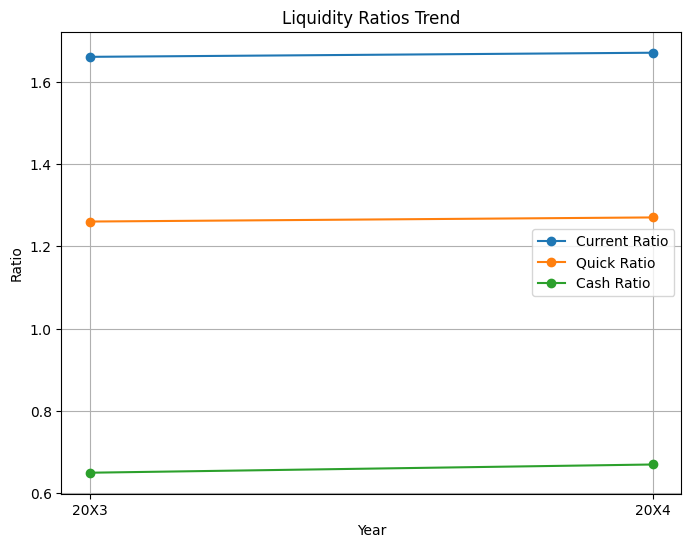

In [5]:
import matplotlib.pyplot as plt

years = ["20X3", "20X4"]
current = [ratios_20X3["Current Ratio"], ratios_20X4["Current Ratio"]]
quick = [ratios_20X3["Quick Ratio"], ratios_20X4["Quick Ratio"]]
cash = [ratios_20X3["Cash Ratio"], ratios_20X4["Cash Ratio"]]

plt.figure(figsize=(8,6))
plt.plot(years, current, marker="o", label="Current Ratio")
plt.plot(years, quick, marker="o", label="Quick Ratio")
plt.plot(years, cash, marker="o", label="Cash Ratio")
plt.title("Liquidity Ratios Trend")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
from fractions import Fraction
# for 20X4

def to_ratio(numerator, denominator):
    ratio = Fraction(numerator, denominator).limit_denominator()
    return f"{ratio.numerator}:{ratio.denominator}"

# for current ratio: Current Assets [25,000] vs Current Liabilities [15,000]
print(to_ratio(25000, 15000))   # Output: 5:3
# for quick ratio: (curret assets-inventory ) [19000] vs current liabilities [15000]
print(to_ratio(19000,15000))
# for cash ratio: cash or cash receivables [10000] vs current liabilities [15000]
print(to_ratio(10000,15000))

5:3
19:15
2:3


In [16]:
# for 20X3
def to_ratio(nuertaor,denominator):
    ratio = Fraction(nuertaor, denominator).limit_denominator()
    return f"{ratio.numerator}:{ratio.denominator}"

#for current ratio: current assets [22900] vs current liabilities [15000]
print(to_ratio(22900,13800))
#for quick ratio: current assets minus inventory [17900] vs current liabilities [13800]
print(to_ratio(17900,13800))
#for cash ratio: cash [9000] vs current liabilities [13800]
print(to_ratio(9000,13800))

229:138
179:138
15:23


In [19]:
summary = pd.DataFrame({
    "Ratio": ["Current Ratio", "Quick Ratio", "Cash Ratio", "Working Capital"],
    "20X3": [ratios_20X3["Current Ratio"], ratios_20X3["Quick Ratio"], ratios_20X3["Cash Ratio"], ratios_20X3["Working Capital"]],
    "20X4": [ratios_20X4["Current Ratio"], ratios_20X4["Quick Ratio"], ratios_20X4["Cash Ratio"], ratios_20X4["Working Capital"]]
})

display(summary)


,Ratio,20X3,20X4
0,Current Ratio,1.66,1.67
1,Quick Ratio,1.26,1.27
2,Cash Ratio,0.65,0.67
3,Working Capital,9100.00,10000.00


In [20]:
print("Conclusion:")
print("The firm's liquidity position remained stable between 20X3 and 20X4.")
print("Current and Quick ratios are above 1, showing healthy short-term solvency.")
print("Cash ratio is below 1, meaning the firm cannot cover all liabilities with cash alone.")
print("Working capital is positive, indicating a buffer to fund operations.")


Conclusion:
The firm's liquidity position remained stable between 20X3 and 20X4.
Current and Quick ratios are above 1, showing healthy short-term solvency.
Cash ratio is below 1, meaning the firm cannot cover all liabilities with cash alone.
Working capital is positive, indicating a buffer to fund operations.
